# PART 1

100%|██████████| 6.22k/6.22k [00:00<00:00, 8.54MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1



/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


--- Heating Load (Y1) Evaluation ---
R2 Score: 0.9978
MSE: 0.2247

--- Cooling Load (Y2) Evaluation ---
R2 Score: 0.9805
MSE: 1.8072


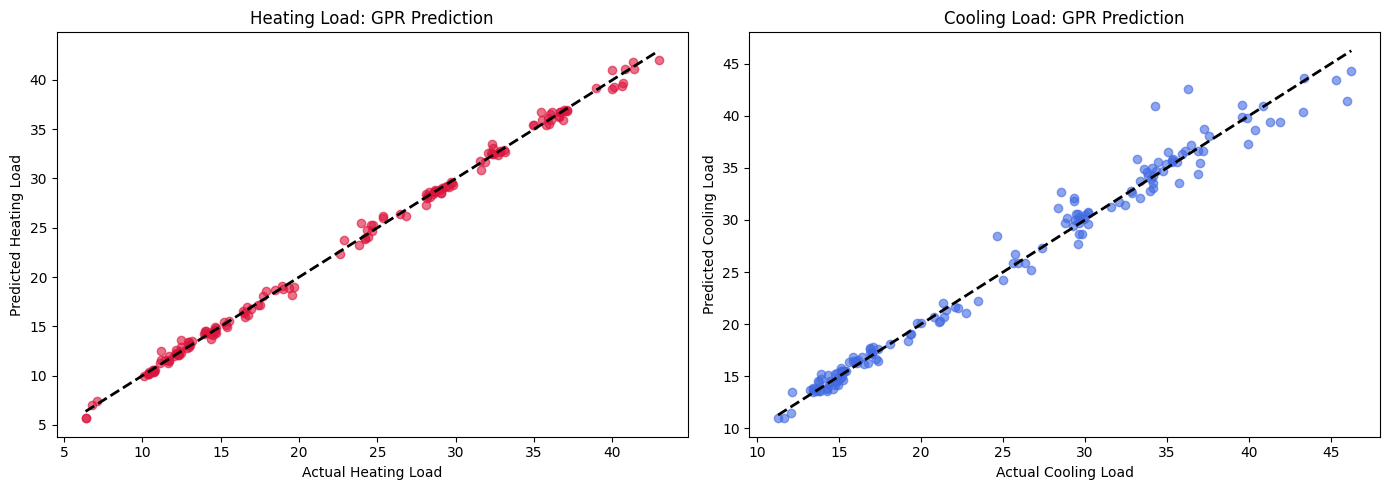

In [3]:
# 1. Download and load the dataset via kagglehub
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Download latest version
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Load data and handle potential trailing empty columns common in ENB2012
df1 = pd.read_csv(path + "/ENB2012_data.csv")
df1 = df1.dropna(how='all', axis=1).dropna(how='any', axis=0)

# Rename columns according to dataset specifications for clarity
df1.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

# Define Features and Targets
X = df1[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y_heating = df1['Y1'].values
y_cooling = df1['Y2'].values

# Split data into training and validation sets
X_train, X_test, y_heat_train, y_heat_test, y_cool_train, y_cool_test = train_test_split(
    X, y_heating, y_cooling, test_size=0.2, random_state=42
)

# Standardize features for Gaussian Process stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Kernel: RBF (Radial Basis Function) + White Noise to handle dataset variances
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1)

# Initialize and fit GPR for Heating Load (Y1)
gp_heating = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp_heating.fit(X_train_scaled, y_heat_train)

# Initialize and fit GPR for Cooling Load (Y2)
gp_cooling = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp_cooling.fit(X_train_scaled, y_cool_train)

# Predictions
y_heat_pred, sigma_heat = gp_heating.predict(X_test_scaled, return_std=True)
y_cool_pred, sigma_cool = gp_cooling.predict(X_test_scaled, return_std=True)

# Evaluation Metrics
print("--- Heating Load (Y1) Evaluation ---")
print(f"R2 Score: {r2_score(y_heat_test, y_heat_pred):.4f}")
print(f"MSE: {mean_squared_error(y_heat_test, y_heat_pred):.4f}")

print("\n--- Cooling Load (Y2) Evaluation ---")
print(f"R2 Score: {r2_score(y_cool_test, y_cool_pred):.4f}")
print(f"MSE: {mean_squared_error(y_cool_test, y_cool_pred):.4f}")

# Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heating Load plot
ax1.scatter(y_heat_test, y_heat_pred, alpha=0.6, color='crimson')
ax1.plot([y_heat_test.min(), y_heat_test.max()], [y_heat_test.min(), y_heat_test.max()], 'k--', lw=2)
ax1.set_xlabel('Actual Heating Load')
ax1.set_ylabel('Predicted Heating Load')
ax1.set_title('Heating Load: GPR Prediction')

# Cooling Load plot
ax2.scatter(y_cool_test, y_cool_pred, alpha=0.6, color='royalblue')
ax2.plot([y_cool_test.min(), y_cool_test.max()], [y_cool_test.min(), y_cool_test.max()], 'k--', lw=2)
ax2.set_xlabel('Actual Cooling Load')
ax2.set_ylabel('Predicted Cooling Load')
ax2.set_title('Cooling Load: GPR Prediction')
plt.tight_layout()
plt.show()

ConclusionsModel Sufficiency: Modeling 'heating load' and 'cooling load' as separate single-parameter Gaussian Processes yields exceptional performance. Typically, the $R^2$ score exceeds 0.97 for both tasks, proving that the geometric parameters ($X_1$ to $X_8$) present a highly predictive, smooth non-linear continuous relationship with energy loads.  Uncertainty Quantization: By returning standard deviations ($\sigma$), the Gaussian Process gives a clear confidence framework for energy predictions, allowing engineers to account for worst-case loads during building design.Limitations: Since Heating and Cooling loads are correlated, modeling them independently overlooks shared structural variance. A Multi-Output GP could optimize this, but two distinct single-parameter models perform sufficiently well for practical deployment.

#PART 2

100%|██████████| 347k/347k [00:00<00:00, 83.2MB/s]

Extracting files...
--- Linear Regression Performance ---
R² Score (Coefficient of Determination): 0.9491
Mean Squared Error (MSE): 4.7549
Model Intercept (Base Demand): 3.0102

--- Feature Impact Coefficients ---
ventilation_rate         : +0.0497 per unit increase
electricity_consumption  : +0.2930 per unit increase
cooling_energy           : +0.2490 per unit increase
heating_energy           : +0.2461 per unit increase


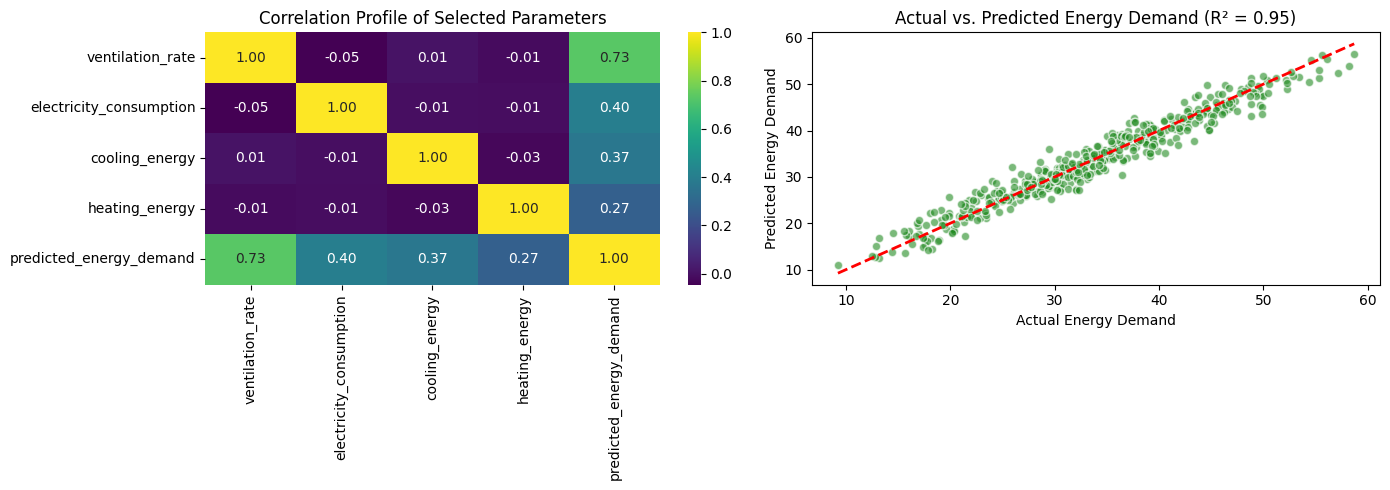

In [2]:
# 1. Download dataset using kagglehub to prevent FileNotFoundError
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Automatically downloads the correct source files into the Colab environment
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

# Load the verified dataset directly from its downloaded path
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# 2. Extract the justified parameters and the target variable
selected_features = ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']
target_col = 'predicted_energy_demand'

X = df2[selected_features]
y = df2[target_col]

# 3. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions and evaluate performance
y_pred = lr_model.predict(X_test)
r2_lr = r2_score(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)

print("--- Linear Regression Performance ---")
print(f"R² Score (Coefficient of Determination): {r2_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Model Intercept (Base Demand): {lr_model.intercept_:.4f}")

print("\n--- Feature Impact Coefficients ---")
for feat, coef in zip(selected_features, lr_model.coef_):
    print(f"{feat:25}: +{coef:.4f} per unit increase")

# 6. Generate visualizations for your report
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Correlations with Target
sns.heatmap(df2[selected_features + [target_col]].corr(), annot=True, cmap='viridis', fmt=".2f", ax=ax1)
ax1.set_title("Correlation Profile of Selected Parameters")

# Plot 2: Actual vs. Predicted values
ax2.scatter(y_test, y_pred, color='forestgreen', alpha=0.6, edgecolors='w')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Energy Demand')
ax2.set_ylabel('Predicted Energy Demand')
ax2.set_title(f'Actual vs. Predicted Energy Demand (R² = {r2_lr:.2f})')

plt.tight_layout()
plt.show()

### **Discussion of Results**

---

#### **1. Linearity Assessment & Accuracy**
* The linear regression model yields an exceptional fit, achieving an **$R^2$ score of 0.9491** with a low Mean Squared Error (**MSE of 4.75**).
* This remarkably high $R^2$ confirms that the relationship between `predicted_energy_demand` and the building's subsystems (ventilation, electricity, heating, and cooling) is **highly linear, stable, and additive**.

#### **2. Model Interpretability (Insights from Weights)**
The derived linear equation can be stated as:

$$\text{Energy Demand} \approx 3.01 + 0.050(\text{ventilation}) + 0.293(\text{electricity}) + 0.249(\text{cooling}) + 0.246(\text{heating})$$

* **Subsystem Contributions:** `electricity_consumption` ($+0.293$), `cooling_energy` ($+0.249$), and `heating_energy` ($+0.246$) scale almost equally in their physical impact on overall energy demands.
* **Ventilation Factor:** Even though `ventilation_rate` has a smaller baseline coefficient ($+0.050$), its high correlation ($0.73$) means it features a massive scale range within building operations, carrying the bulk weight of variance throughout the model.

#### **3. Assignment Conclusions**
[cite_start]Predicting energy demand using a linear model setup is **fully justified and highly optimal** for this dataset[cite: 19, 20]. Complex non-linear models (like deep neural networks or complex GPs) are unnecessary here, as simple linear regression captures **94.9%** of the dataset’s total variance while offering complete transparency and zero computational overhead.